## Data Visualization with Matplotlib: Programming Languages

#### Get the Data
Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange:
Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
SELECT dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
FROM PostTags pt
join Posts q ON q.Id=pt.PostId
join Tags t ON t.Id=pt.TagId
WHERE TagName in (
  'ada','assembly','awk',
  'bash','basic',
  'c','c++','c#','clojure','cobol','coffeescript','curl',
  'delphi',
  'fortran',
  'go','groovy',
  'haskell',
  'java','javascript','julia',
  'kotlin',
  'matlab',
  'objective-c',
  'pascal','perl','php','prolog','python',
  'r','ruby','rust',
  'scala','sql','sqift',
  'typescript'
)
AND q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
-- AND q.CreationDate >= '2024-01-01'  -- Start of fixed period
-- AND q.CreationDate < '2026-01-01'   -- End of fixed period (exclusive)
GROUP BY dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
ORDER BY dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

Read the .csv file and store it in a Pandas DataFrame called `df`. Have a look at the [read_csv() documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) and try to provide these column names: `['DATE', 'TAG', 'POSTS']`

In [305]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/programming_languages.csv", names=['DATE','TAG','POSTS'], header=0)

Next, we use `.head()` and `.tail()` to look at the first and last 5 rows. This allows us to verify that our column naming worked as intended.

In [104]:
df.head()

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,awk,2
3,2008-08-01 00:00:00,bash,21
4,2008-08-01 00:00:00,c,82


In [106]:
df.tail()

,DATE,TAG,POSTS
6689,2025-08-01 00:00:00,ruby,18
6690,2025-08-01 00:00:00,rust,95
6691,2025-08-01 00:00:00,scala,9
6692,2025-08-01 00:00:00,sql,94
6693,2025-08-01 00:00:00,typescript,206


To check the dimensions of the DataFrame, we use our old friend `.shape`

In [109]:
df.shape

(6694, 3)

To count the number of entries in each column we can use .count(). Note that `.count()` will actually tell us the number of non-NaN values in each column.

In [112]:
df.count()

DATE     6694
TAG      6694
POSTS    6694
dtype: int64

#### Analysis by Programming Language

The TAG is the name of the programming language. So for example in July 2008, there were 3 posts tagged with the language C#. Given that the TAG serves as our category column, can you figure out how to count the number of posts per language? Which programming language had the most number of posts since the creation of Stack Overflow?

Also, some languages are older like C and other languages are newer (like Swift). The dataset starts in July 2008, so some languages will not have any posts for every month. Can you count how many months of posts exist for each programming language?

In order to look at the number of entries and the number of posts by programming language, we need to make use of the `.groupby()` method. The key is combining `.groupby()` with the TAG column, which holds as our categories (the names of the programming languages).

If we `.sum()` the number of posts then we can see how many posts each programming language had.

In [143]:
df.groupby('TAG')[['POSTS']].sum()

,POSTS
TAG,
ada,2442
assembly,45142
awk,33274
bash,156825
basic,877
c,408056
c#,1624072
c++,814756
clojure,17757


If we `.count()` the entries in each column, we can see how many months of entries exist per programming language.

In [146]:
df.groupby('TAG').count()

,DATE,POSTS
TAG,,
ada,201,201
assembly,205,205
awk,205,205
bash,205,205
basic,183,183
c,205,205
c#,206,206
c++,205,205
clojure,204,204


### Data Cleaning: Working with Time Stamps

#### Selecting an Individual Cell

Let's take a closer look at the 'DATE' column in our DataFrame. We can use the double square bracket notation to look at the second entry in the column: 

In [170]:
df['DATE'][0]

'2008-07-01 00:00:00'

Alternatively, for column names no spaces, we can also use the dot-notation:

In [173]:
df.DATE[0]

'2008-07-01 00:00:00'

I prefer the square bracket notation for column names since it's more flexible, but with the dot notation, you get to use autocomplete, which is also nice.

#### Data Cleaning
Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of '2008-07-01 00:00:00' to a datetime object with the format of '2008-07-01'

#### Inspecting the Data Type
When we type check the contents of this cell, we see that we are not dealing with a date object, but rather with a string.

In [179]:
type(df['DATE'][0])

str

This is not very handy. Not only will the string format always show the unnecessary 00:00:00, but we also don't get the benefit of working with Datetime objects, which know how to handle dates and times. Pandas can help us convert the string to a timestamp using the [to_datetime()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html) method.

Here's how we can convert the entry in our cell and check that it worked:

In [192]:
print(pd.to_datetime(df.DATE[0]))
type(pd.to_datetime(df.DATE[0]))

2008-07-01 00:00:00


pandas._libs.tslibs.timestamps.Timestamp

Let's use Pandas' `to_datetime()` to convert the entire `df['DATE']`column.

In [197]:
# Convert Entire Column
df.DATE = pd.to_datetime(df.DATE)
df.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,awk,2
3,2008-08-01,bash,21
4,2008-08-01,c,82


Here's how to convert a pandas column from string to datetime using the `apply()` function:

In [203]:
df.DATE = df.DATE.apply(pd.to_datetime)
df.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,awk,2
3,2008-08-01,bash,21
4,2008-08-01,c,82


You can also specify format and handle errors:

In [205]:
# With specific format
df.DATE = df.DATE.apply(lambda x: pd.to_datetime(x, format='%Y-%m-%d'))
df.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,awk,2
3,2008-08-01,bash,21
4,2008-08-01,c,82


Excellent. Now we can start thinking about how to manipulate our data so that we get a one column per programming language.

### Data Manipulation: Pivoting DataFrames
#### The [.pivot()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html) method
Sometimes you want to convert your DataFrame so that each category has its own column. For example, suppose you needed to take the table below and create a separate column for each actor, where each row is the Age of the actor:

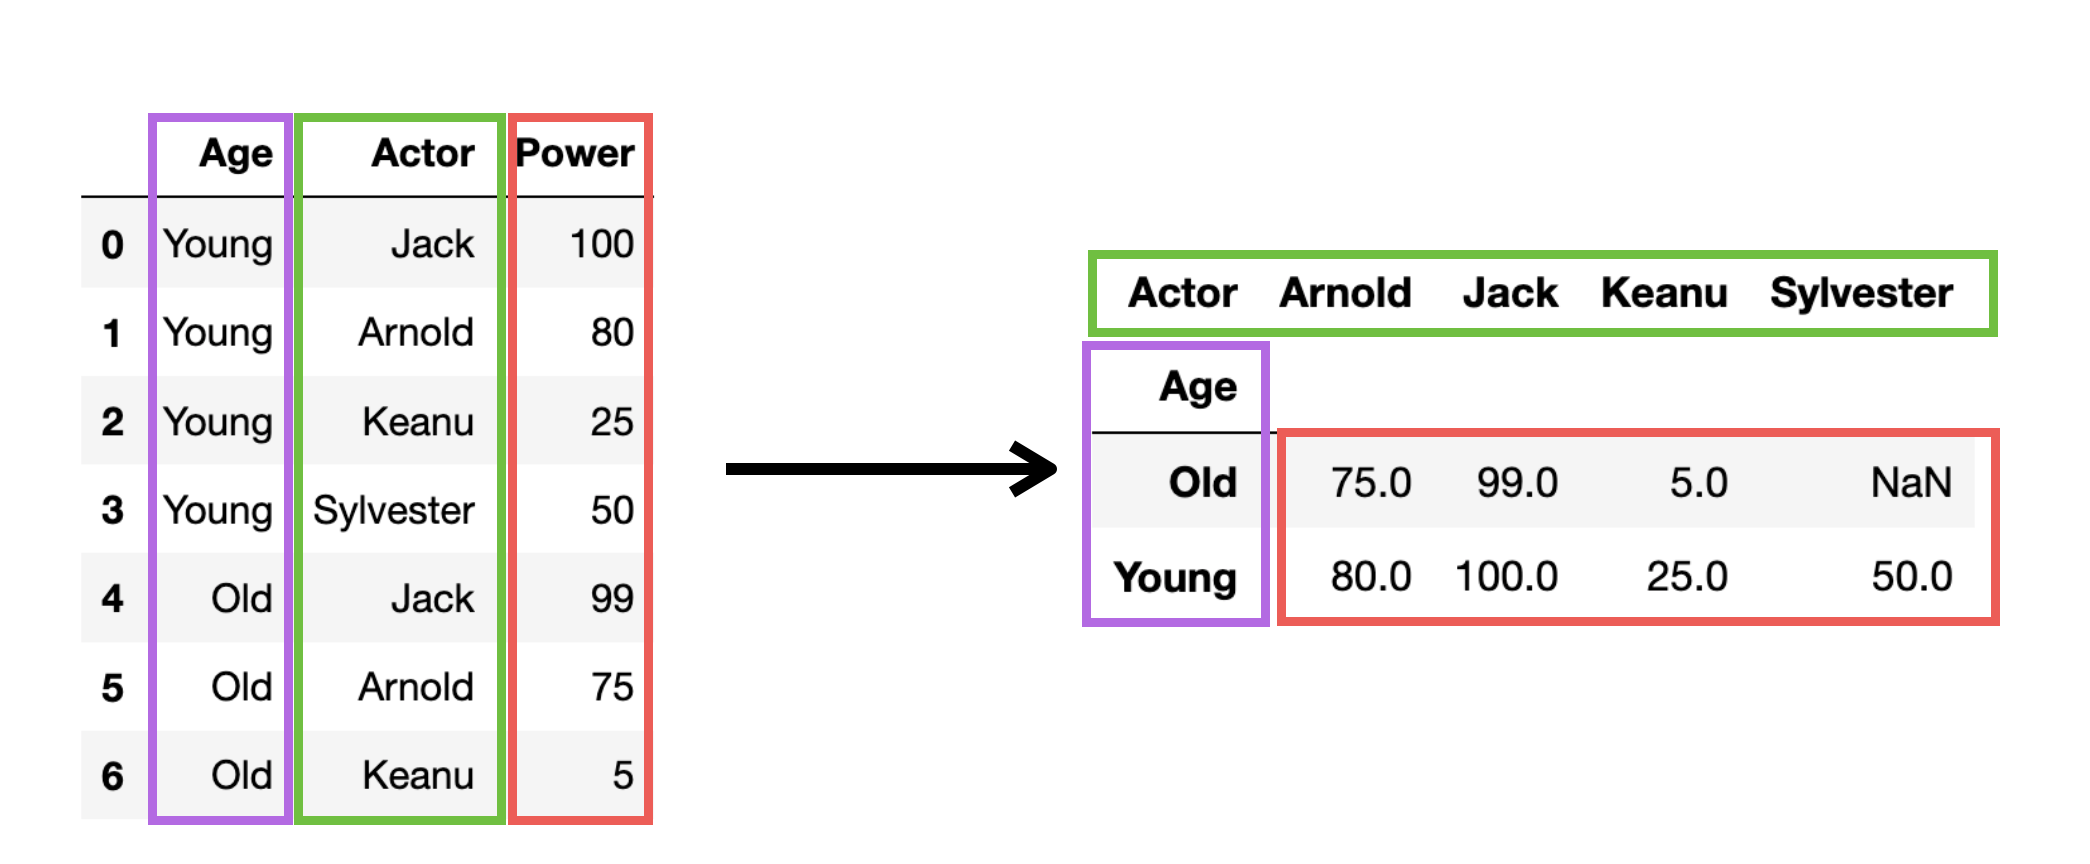

In [244]:
from IPython.display import Image, display, HTML

display(Image(filename='img/073_03.png', width=640))

How would you do this with the DataFrame below? 

In [254]:
test_df = pd.DataFrame({'Age': ['Young', 'Young', 'Young', 'Young', 'Old', 'Old', 'Old'],
                        'Actor': ['Jack', 'Arnold', 'Keanu', 'Sylvester', 'Jack', 'Arnold', 'Keanu'],
                        'Power': [100, 80, 25, 50, 99, 75, 5]})
test_df

,Age,Actor,Power
0,Young,Jack,100
1,Young,Arnold,80
2,Young,Keanu,25
3,Young,Sylvester,50
4,Old,Jack,99
5,Old,Arnold,75
6,Old,Keanu,5


The easiest way to accomplish this is by using the `.pivot()` method in Pandas. The thing to understand is how to supply the correct aguments to get the desired outcome. The index are the categories for the rows. The columns are the categories for the columns. And the values are what you want in the new cells. 

In [257]:
pivoted_df = test_df.pivot(index='Age', columns='Actor', values='Power')
pivoted_df

Actor,Arnold,Jack,Keanu,Sylvester
Age,,,,
Old,75.0,99.0,5.0,NaN
Young,80.0,100.0,25.0,50.0


However, there's one very important thing to notice. What happens if a value is missing? In the example above there's no value for old Sylvester. In this case, the `.pivot()` method will insert a NaN value.

#### Mini-Challenge
- Pivot the df DataFrame so that each row is a date and each column is a programming language? Store the result under a variable called reshaped_df.
- Examine the dimensions of the reshaped DataFrame. How many rows does it have? How many columns?
- Examine the head and the tail of the DataFrame. What does it look like?
- Print out the column names.
- Count the number of entries per column.

In [276]:
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS')

In [272]:
reshaped_df.shape

(206, 34)

In [274]:
reshaped_df.columns

Index(['ada', 'assembly', 'awk', 'bash', 'basic', 'c', 'c#', 'c++', 'clojure',
       'cobol', 'coffeescript', 'curl', 'delphi', 'fortran', 'go', 'groovy',
       'haskell', 'java', 'javascript', 'julia', 'kotlin', 'matlab',
       'objective-c', 'pascal', 'perl', 'php', 'prolog', 'python', 'r', 'ruby',
       'rust', 'scala', 'sql', 'typescript'],
      dtype='object', name='TAG')

In [278]:
reshaped_df.head()

TAG,ada,assembly,awk,bash,basic,c,c#,c++,clojure,cobol,...,perl,php,prolog,python,r,ruby,rust,scala,sql,typescript
DATE,,,,,,,,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,NaN,8.0,2.0,21.0,NaN,82.0,503.0,164.0,NaN,NaN,...,28.0,157.0,NaN,119.0,NaN,68.0,NaN,NaN,143.0,NaN
2008-09-01,3.0,28.0,3.0,65.0,1.0,320.0,1638.0,752.0,3.0,4.0,...,128.0,472.0,NaN,534.0,6.0,285.0,NaN,6.0,502.0,NaN
2008-10-01,1.0,16.0,3.0,58.0,1.0,302.0,1982.0,804.0,7.0,3.0,...,128.0,603.0,2.0,504.0,NaN,246.0,NaN,7.0,534.0,NaN
2008-11-01,3.0,16.0,10.0,41.0,NaN,258.0,1728.0,733.0,8.0,1.0,...,97.0,497.0,6.0,447.0,1.0,154.0,NaN,5.0,413.0,NaN


We have 206 rows and 34 columns in the new DataFrame. Each programming language became a column and our date column became the new index (i.e., the label for the rows).

When we count the number of entries per column we see that not all languages are the same. The reason is that the `.count()` method excludes `NaN` values. When we pivoted the DataFrame the `NaN` values were inserted when there were no posts for a language in that month (e.g., Ada in July, 2008).

In [281]:
reshaped_df.count()

TAG
ada             201
assembly        205
awk             205
bash            205
basic           183
c               205
c#              206
c++             205
clojure         204
cobol           201
coffeescript    162
curl            205
delphi          205
fortran         205
go              190
groovy          205
haskell         205
java            205
javascript      205
julia           158
kotlin          171
matlab          205
objective-c     205
pascal          198
perl            205
php             205
prolog          201
python          205
r               203
ruby            205
rust            160
scala           204
sql             205
typescript      157
dtype: int64

#### Dealing with Nan Values

In this case, we don't want to drop the rows that have a `NaN` value. Instead, we want to substitute the number 0 for each `NaN` value in the DataFrame. We can do this with the `.fillna()` method.

In [285]:
reshaped_df.fillna(0, inplace=True)

The ``inplace argument means that we are updating `reshaped_df`. Without this argument we would have to write something like this:
```python
reshaped_df = reshaped_df.fillna(0) 
```

Let's check if we successfully replaced all the `NaN` values in our DataFrame.

In [289]:
reshaped_df.head()

TAG,ada,assembly,awk,bash,basic,c,c#,c++,clojure,cobol,...,perl,php,prolog,python,r,ruby,rust,scala,sql,typescript
DATE,,,,,,,,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,0.0,8.0,2.0,21.0,0.0,82.0,503.0,164.0,0.0,0.0,...,28.0,157.0,0.0,119.0,0.0,68.0,0.0,0.0,143.0,0.0
2008-09-01,3.0,28.0,3.0,65.0,1.0,320.0,1638.0,752.0,3.0,4.0,...,128.0,472.0,0.0,534.0,6.0,285.0,0.0,6.0,502.0,0.0
2008-10-01,1.0,16.0,3.0,58.0,1.0,302.0,1982.0,804.0,7.0,3.0,...,128.0,603.0,2.0,504.0,0.0,246.0,0.0,7.0,534.0,0.0
2008-11-01,3.0,16.0,10.0,41.0,0.0,258.0,1728.0,733.0,8.0,1.0,...,97.0,497.0,6.0,447.0,1.0,154.0,0.0,5.0,413.0,0.0


We can also check if there are any NaN values left in the entire DataFrame with this line:

In [292]:
reshaped_df.isna().values.any()

False

Here we are using the `.isna()` method that we've used before, but we're chaining two more things: the `values` attribute and the `any()` method. This means we don't have to search through the entire DataFrame to spot if `.isna()` is `True`.

Now we're all set to create some charts and visualise our data.

### Data Visualization with Matplotlib
#### Matplotlib
To create our first charts we're going to use a library called [Matplotlib](https://matplotlib.org/). There are many different libraries in Python to help us create charts and graphs. Matplotlib is an incredibly popular one and it works beautifully in combination with Pandas, so let's check it out.

First, we have to import Matplotlib.

```python
import matplotlib.pyplot as plt
```
and let's do this at the top:
```python
import pandas as pd
import matplotlib.pyplot as plt
```

#### Mini Challenge
You can actually show a line chart for the popularity of a programming language using only a single line of code. Can you use the [.plot() documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) to figure out how to do this? Try and plot the popularity of the Java programming language. Here's what you're aiming for:

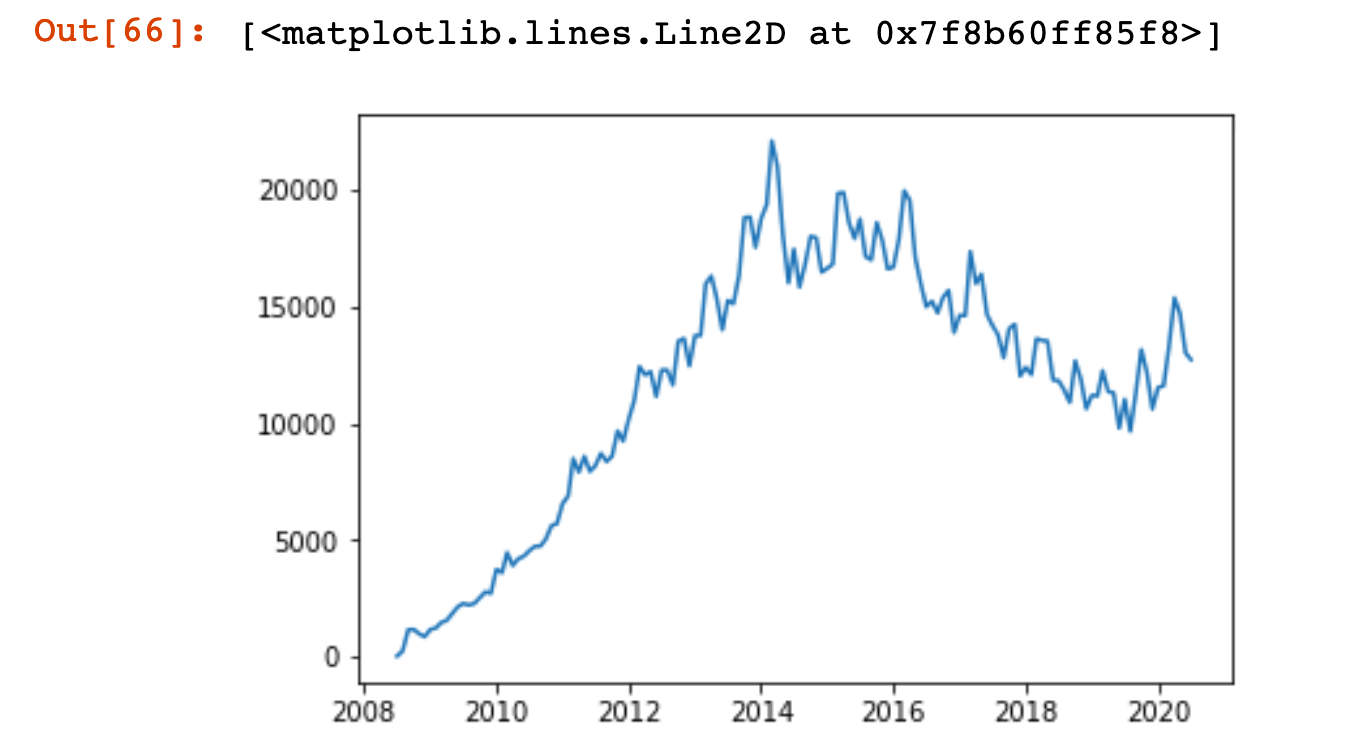

In [308]:
display(Image(filename='img/073_04.png', width=640))

All you need to do is supply the values for the horizontal axis (the x-values) and the vertical axis (the y-values) for the chart. The x-values are our dates and the y-values are the number of posts. We can supply these values to the .plot() function by position like so:

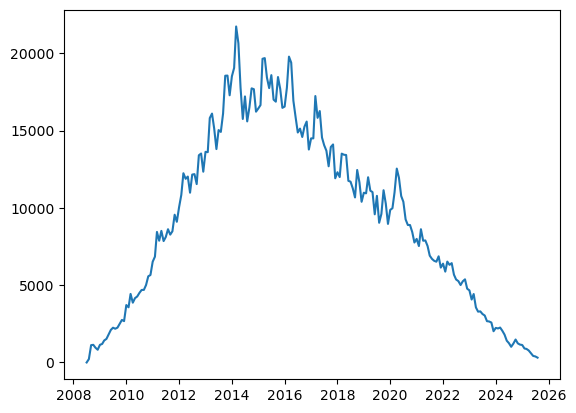

In [337]:
plt.plot(reshaped_df.index, reshaped_df.java)
# or like so if you prefer the square bracket notation.
# plt.plot(reshaped_df.index, reshaped_df['java'])

#### Styling the Chart
Let's look at a couple of methods that will help us style our chart:
- `.figure()` - allows us to resize our chart
- `.xticks()` - configures our x-axis
- `.yticks()` - configures our y-axis
- `.xlabel()` - add text to the x-axis
- `.ylabel()` - add text to the y-axis
- `.ylim()` - allows us to set a lower and upper bound
To make our chart larger we can provide a width (16) and a height (10) as the `figsize` of the figure.

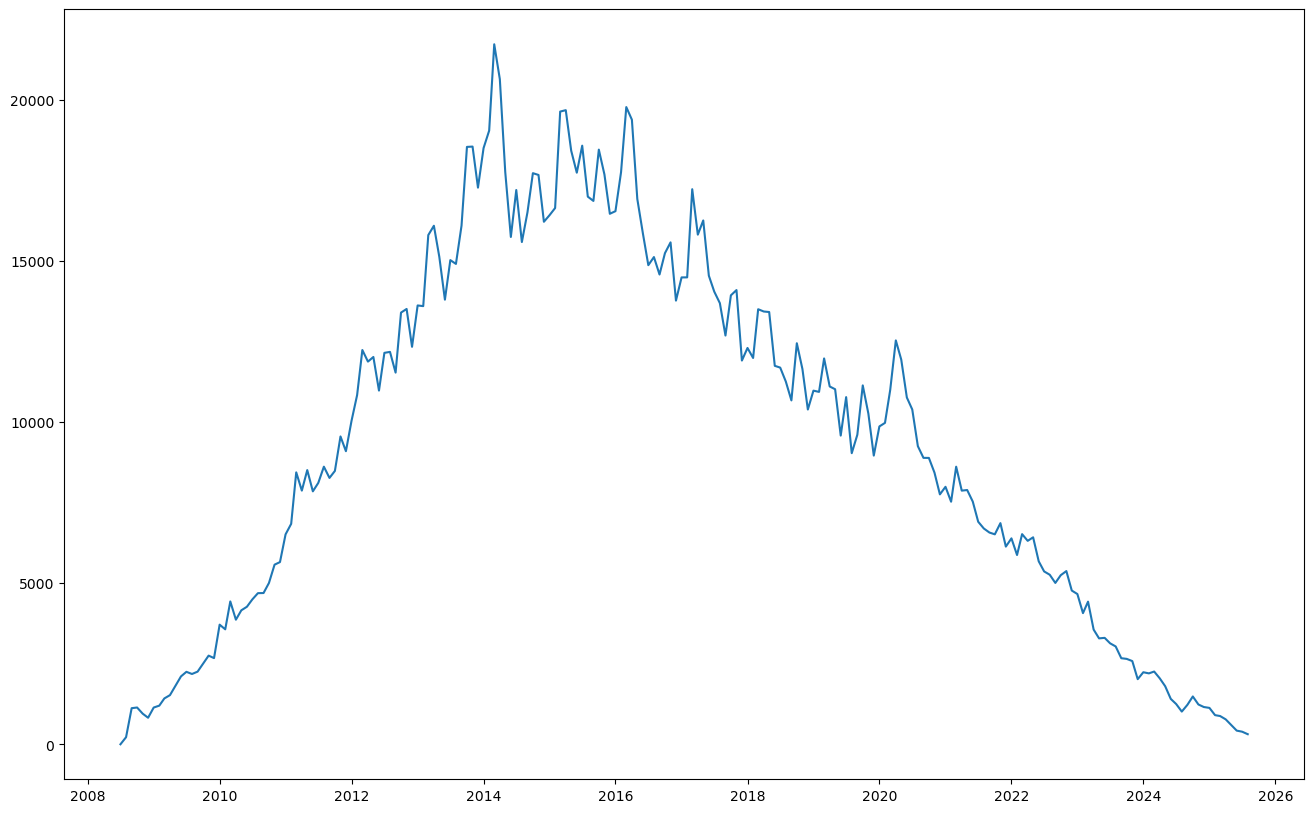

In [345]:
plt.figure(figsize=(16,10))
plt.plot(reshaped_df.index, reshaped_df.java)

This will make our chart easier to see. But when we increase the size of the chart, we should also increase the fontsize of the ticks on our axes so that they remain easy to read:

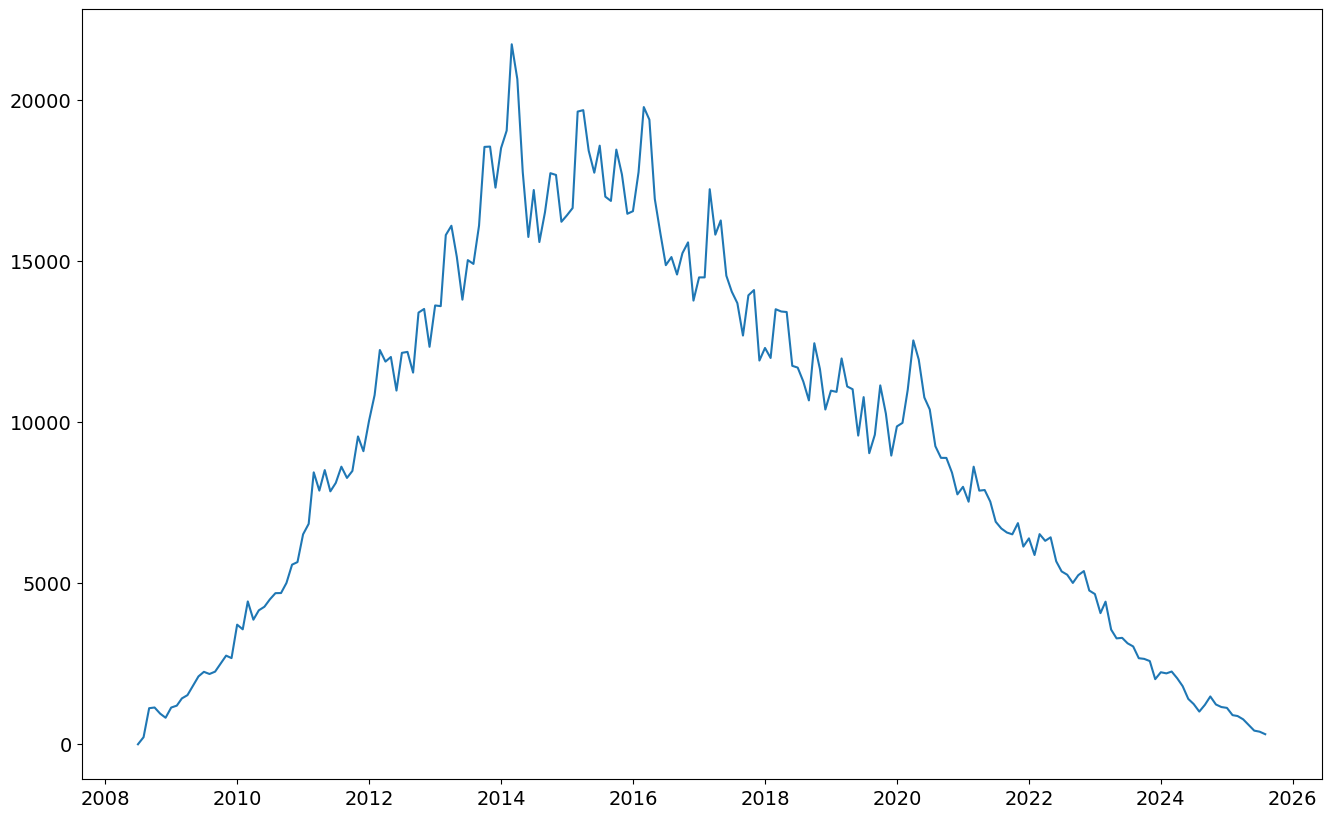

In [348]:
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.plot(reshaped_df.index, reshaped_df.java)

Now we can add labels. Also, we're never going to get less than 0 posts, so let's set a lower limit of 0 for the y-axis with `.ylim()`.

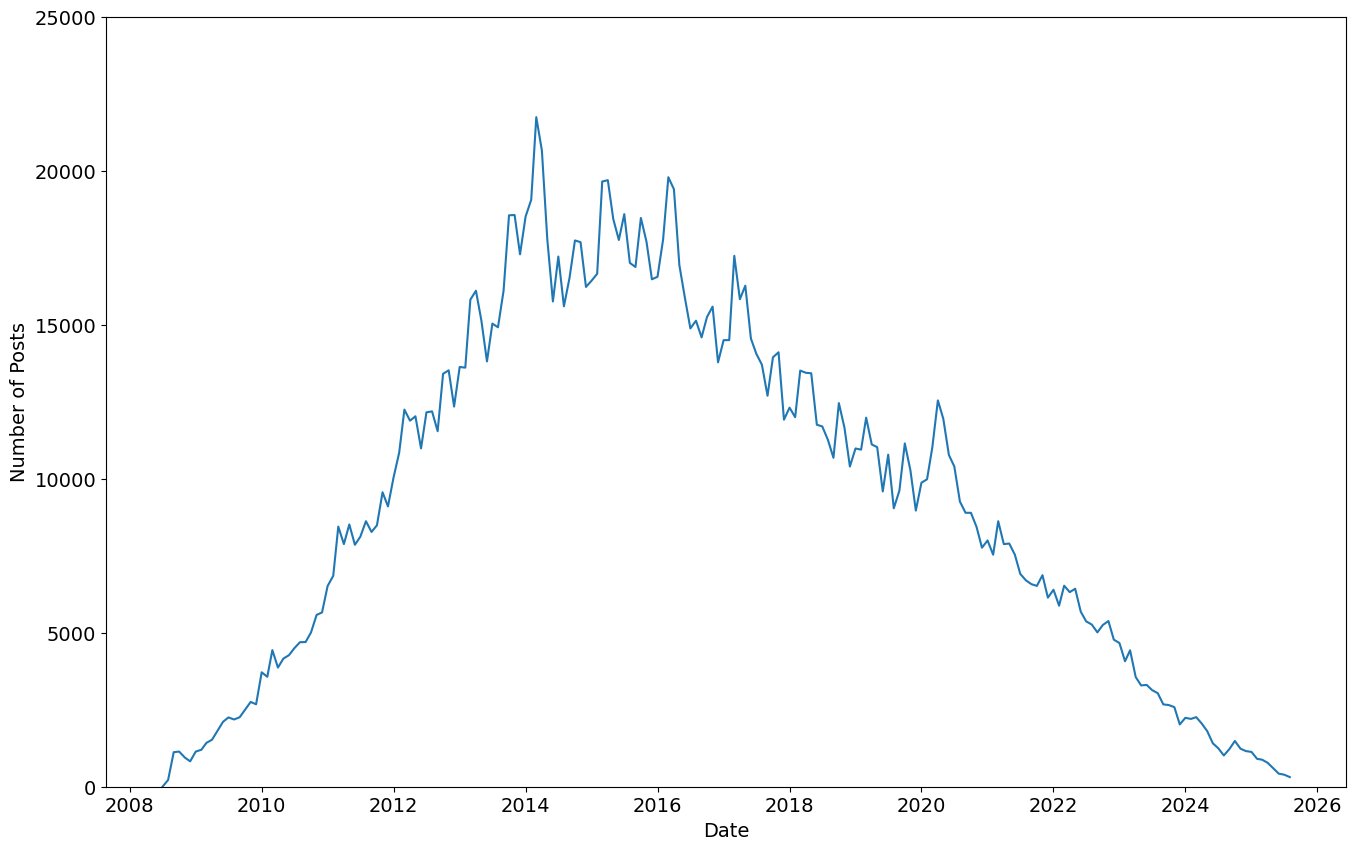

In [359]:
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 25000)
plt.plot(reshaped_df.index, reshaped_df.java)

#### Challenge
Now that you've successfully created and styled your chart, can you figure out how to plot both Java and Python next to each other? The result should look something like this:

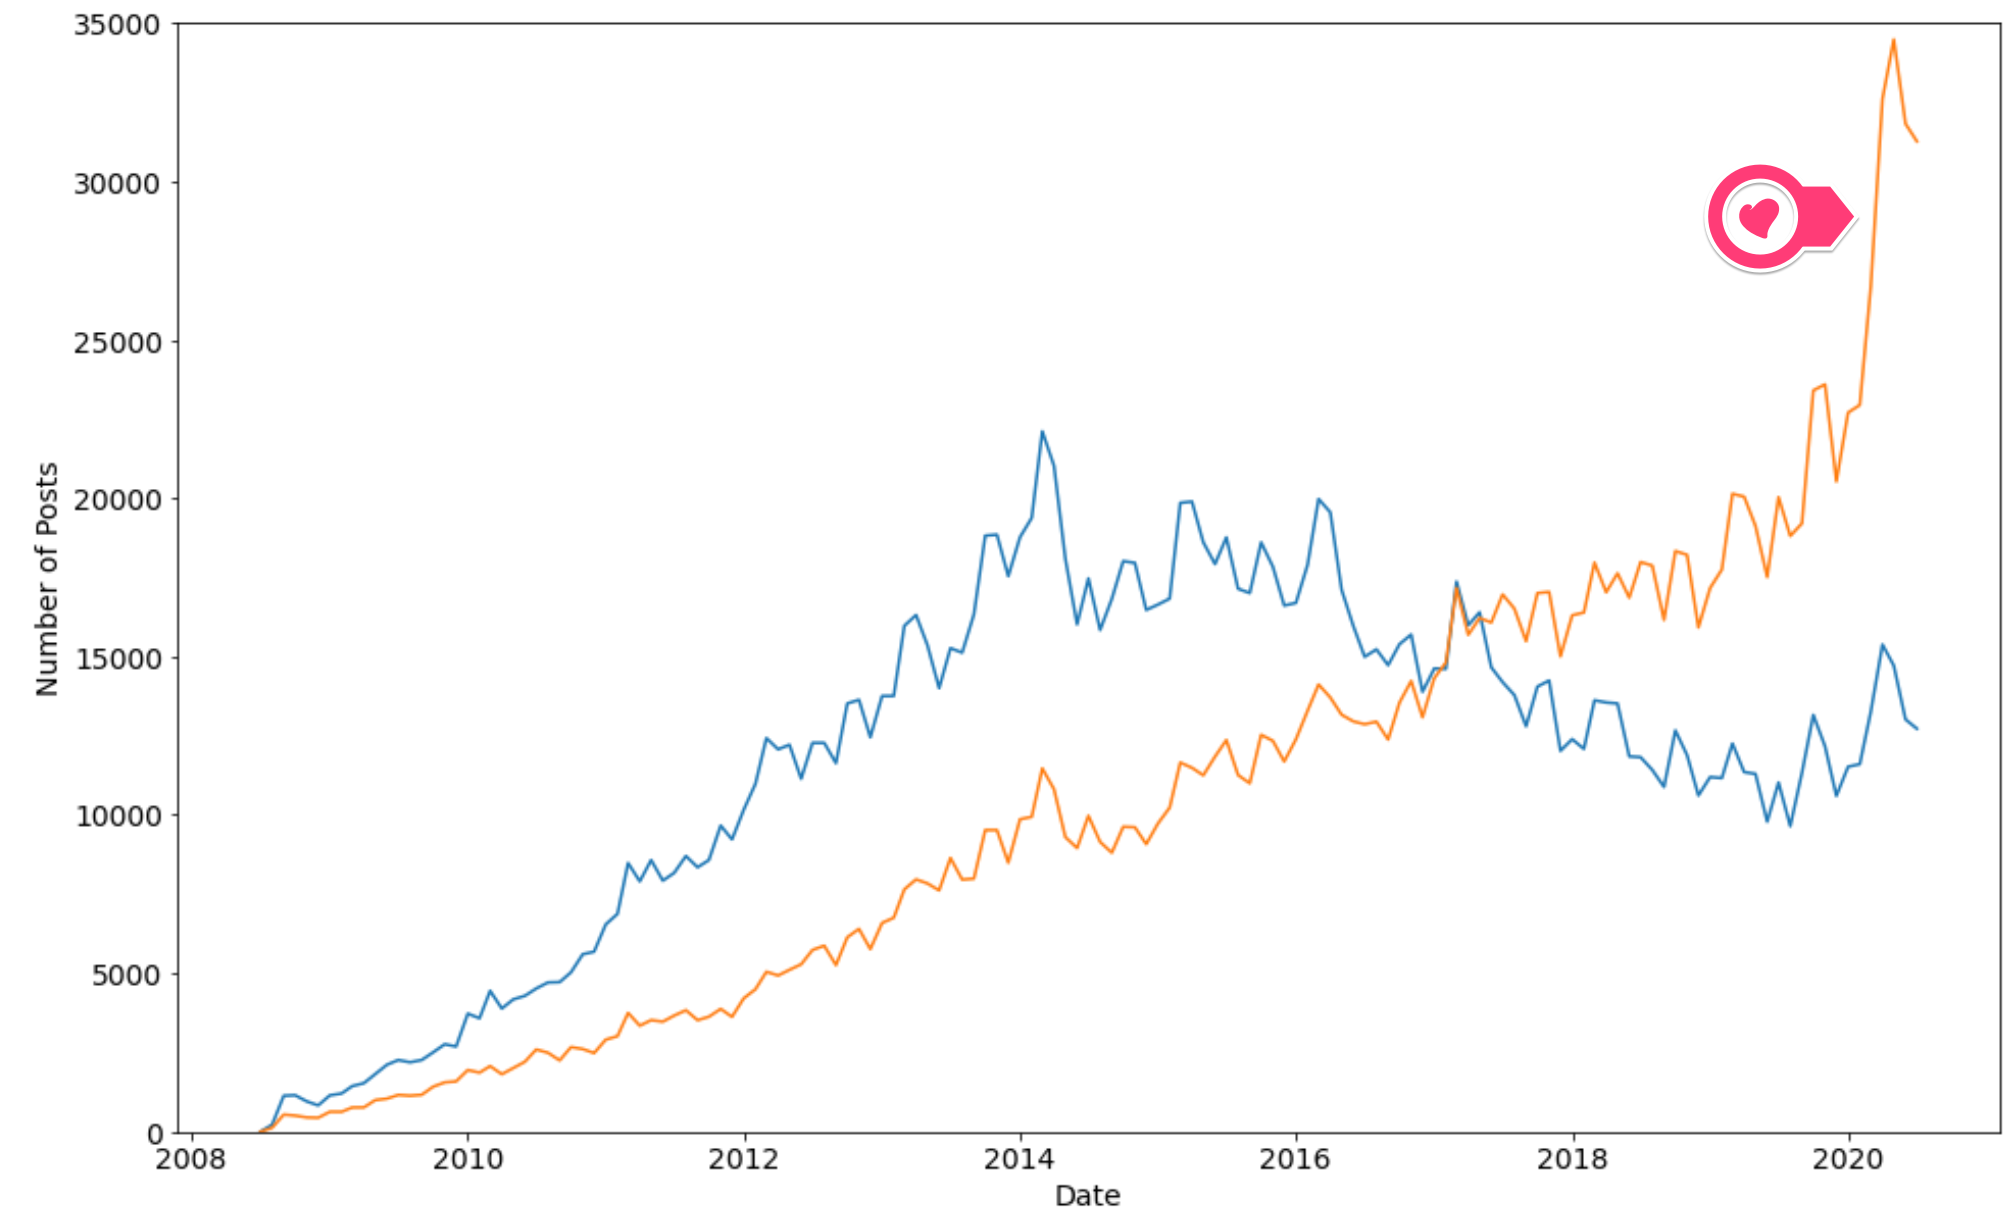

In [364]:
display(Image(filename='img/073_05.png', width=640))

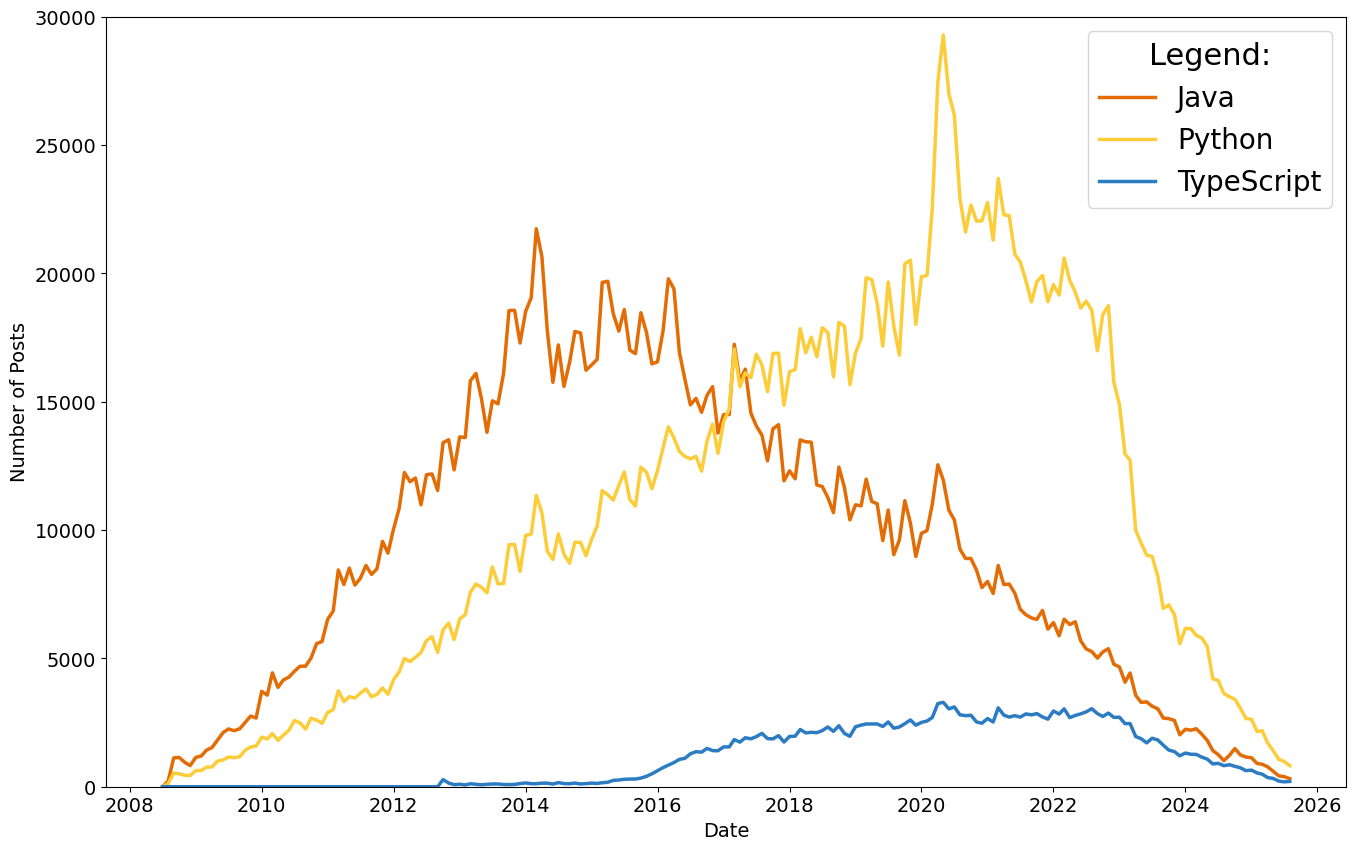

In [430]:
java_color = '#e46c04'
python_color = '#fccc39'
typescript_color = '#2c7cc4'

plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 30000)
plt.plot(reshaped_df.index, reshaped_df.java, color=java_color, label='Java', linewidth=2.5)
plt.plot(reshaped_df.index, reshaped_df.python, color=python_color, label='Python', linewidth=2.5)
plt.plot(reshaped_df.index, reshaped_df.typescript, color=typescript_color, label='TypeScript', linewidth=2.5)
plt.legend(title='Legend:', title_fontsize=22, fontsize=20)

### Multi-Line Charts with Matplotlib
But what if we wanted to plot all the programming languages on the same chart? We don't want to type out .plot() a million times, right? We can actually just use a for-loop:

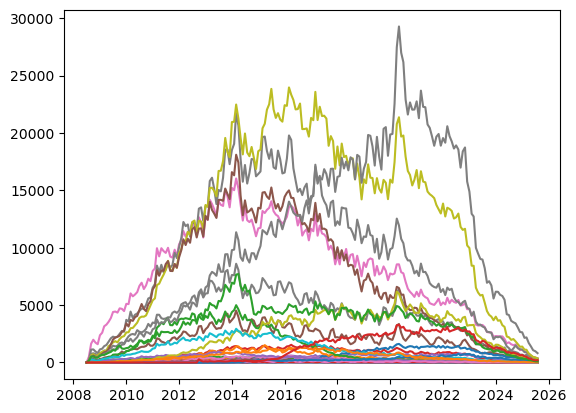

In [435]:
for column in reshaped_df.columns:
    plt.plot(reshaped_df.index, reshaped_df[column])

This will allow us to iterate over each column in the DataFrame and plot it on our chart. The final result should look like this:

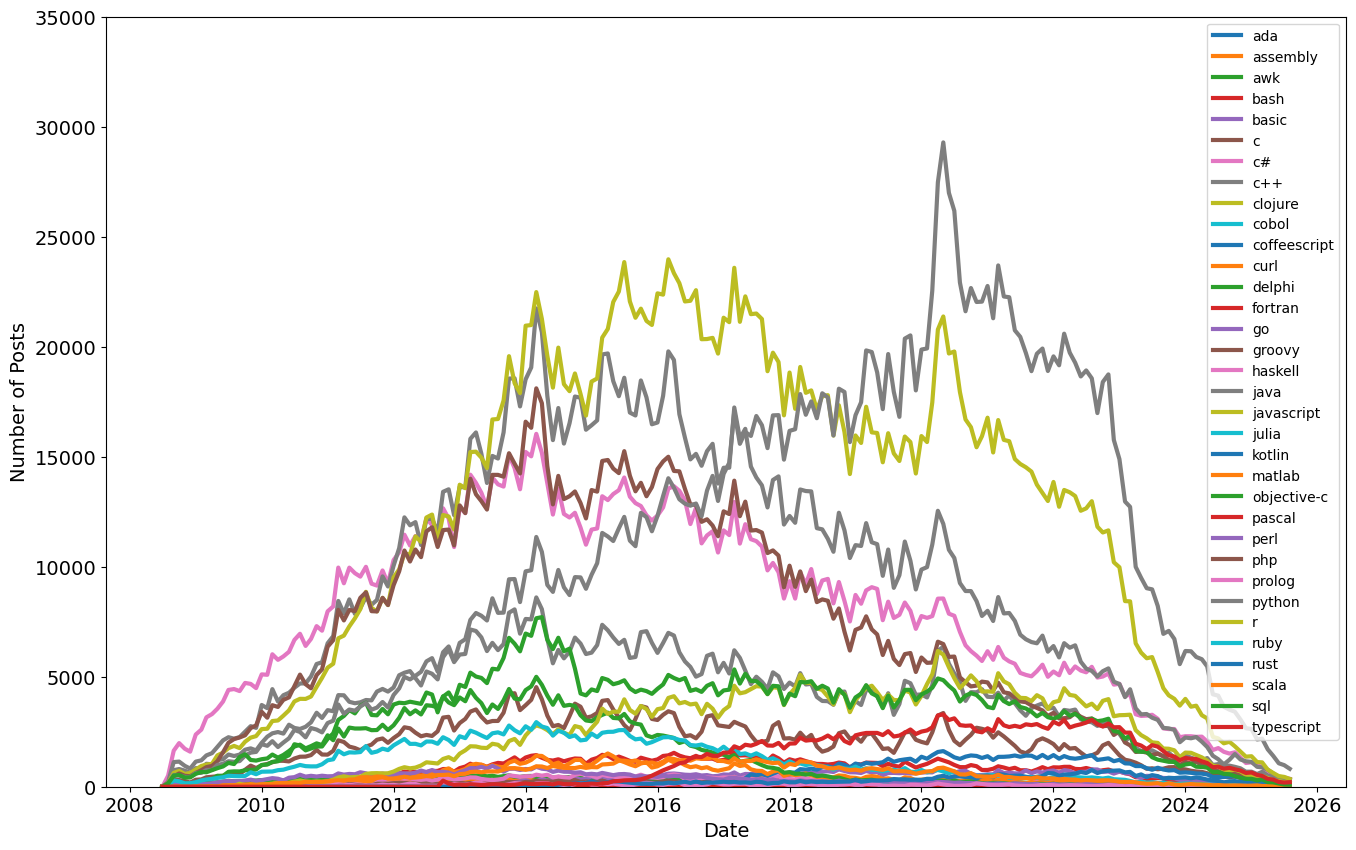

In [450]:
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
 
for column in reshaped_df.columns:
    plt.plot(reshaped_df.index, reshaped_df[column], 
             linewidth=3, label=reshaped_df[column].name)
 
plt.legend(fontsize=10) 

Looks like Python is the most popular programming language judging by the number of posts on Stack Overflow.

### Smoothing out Time-Series Data
Looking at our chart we see that time-series data can be quite noisy, with a lot of up and down spikes. This can sometimes make it difficult to see what's going on.

A useful technique to make a trend apparent is to smooth out the observations by taking an average. By averaging say, 6 or 12 observations we can construct something called the rolling mean. Essentially we calculate the average in a window of time and move it forward by one observation at a time.

Since this is such a common technique, Pandas actually two handy methods already built-in: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). We can chain these two methods up to create a DataFrame made up of the averaged observations.

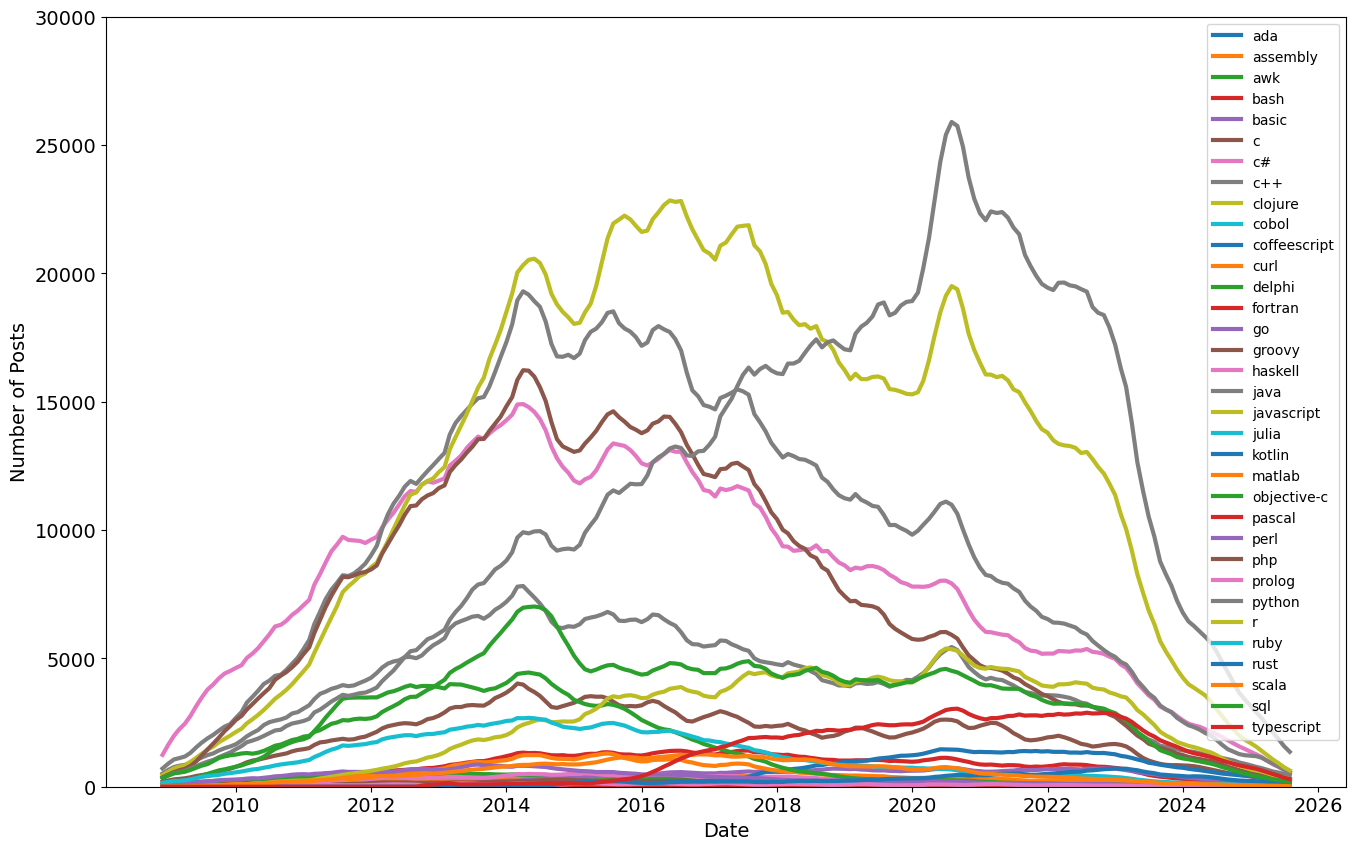

In [463]:
# The window is number of observations that are averaged
roll_df = reshaped_df.rolling(window=6).mean()
 
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 30000)
 
# plot the roll_df instead
for column in roll_df.columns:
    plt.plot(roll_df.index, roll_df[column], 
             linewidth=3, label=roll_df[column].name)
 
plt.legend(fontsize=10)

We can play with the window argument (use 3 or 12) and see how the chart changes. We can also use a subset of all the programming languages in the data.

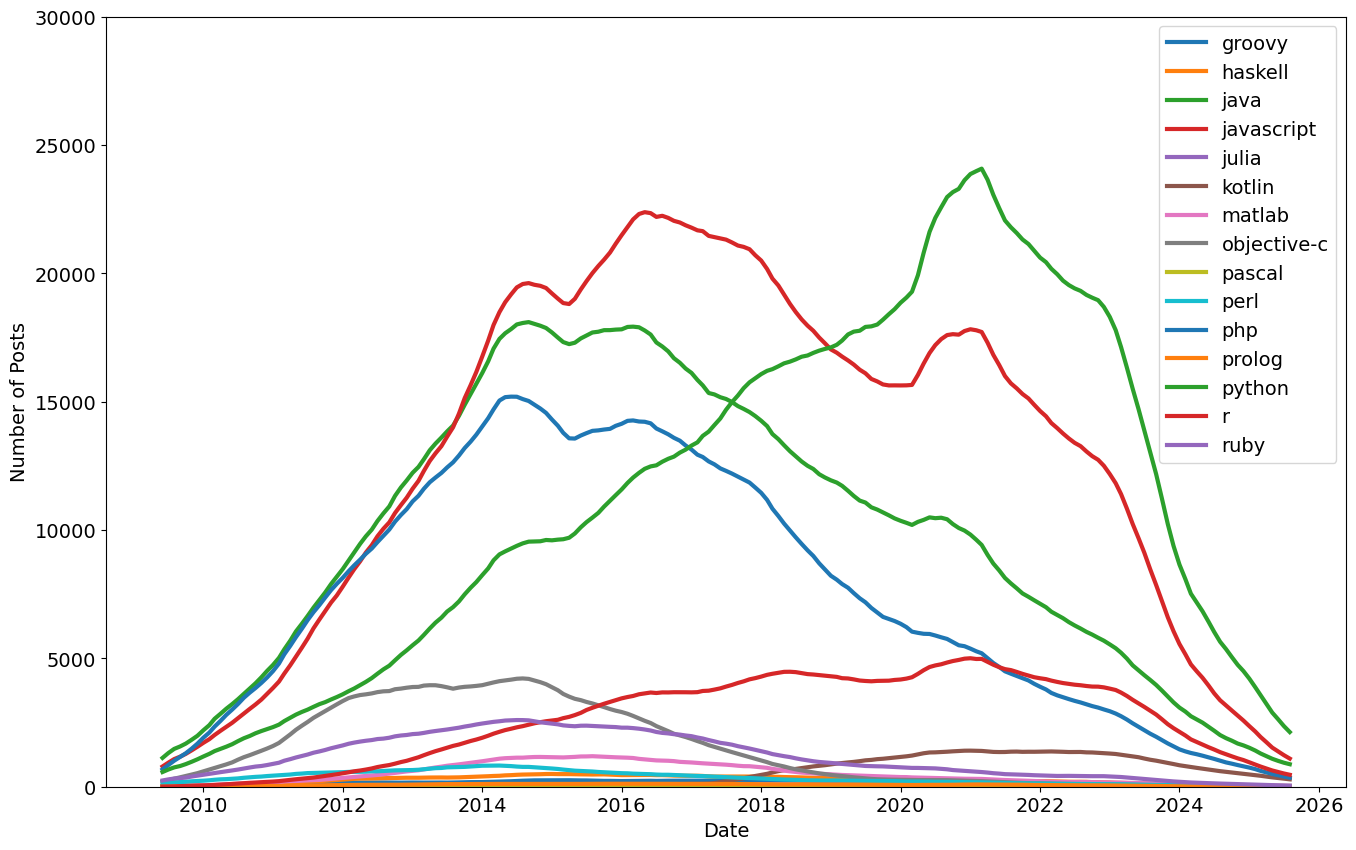

In [480]:
roll_df = reshaped_df.rolling(window=12).mean()
 
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 30000)
 
for column in roll_df.columns[15:30]:
    plt.plot(roll_df.index, roll_df[column], 
             linewidth=3, label=roll_df[column].name)
 
plt.legend(fontsize=14)

### Learning Points & Summary
We've seen how to grab some raw data and create some interesting charts using Pandas and Matplotlib. We've:
- used `.groupby()` to explore the number of posts and entries per programming language;
- converted strings to Datetime objects with `to_datetime()` for easier plotting;
- reshaped our DataFrame by converting categories to columns using `.pivot()`;
- used `.count()` and `isna().values.any()` to look for NaN values in our DataFrame, which we then replaced using `.fillna()`;
- created (multiple) line charts using `.plot()` with a for-loop;
- styled our charts by changing the size, the labels, and the upper and lower bounds of our axis;
- added a legend to tell apart which line is which by colour;
- smoothed out our time-series observations with `.rolling().mean()` and plotted them to better identify trends over time..